# Portfolio Optimization Task - Submission
**Name:** DOMU FIDELIS

In [1]:
# Install pymoo
!pip install -U pymoo


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 1. Select 10 Indonesian stocks based on name
Stocks selected picked based on DOMU FI_ELIS:
DEWA, OASA, MEDC, UNTR, FILM, INDF, EXCL, LSIP, ISAT, SMGR
### 2. Collect daily closing price data for 7-year period

In [10]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. Select 10 Indonesian stocks based on DOMU FI ELIS
tickers = ['DEWA.JK', 'OASA.JK', 'MEDC.JK', 'UNTR.JK', 'FILM.JK', 
           'INDF.JK', 'EXCL.JK', 'LSIP.JK', 'ISAT.JK', 'SMGR.JK']

# 2. Select daily closing price data for 7-year period
print("Downloading stock data...")
data = yf.download(tickers, period='7y')['Close']
data = data.ffill().dropna()

[*********************100%***********************]  10 of 10 completed


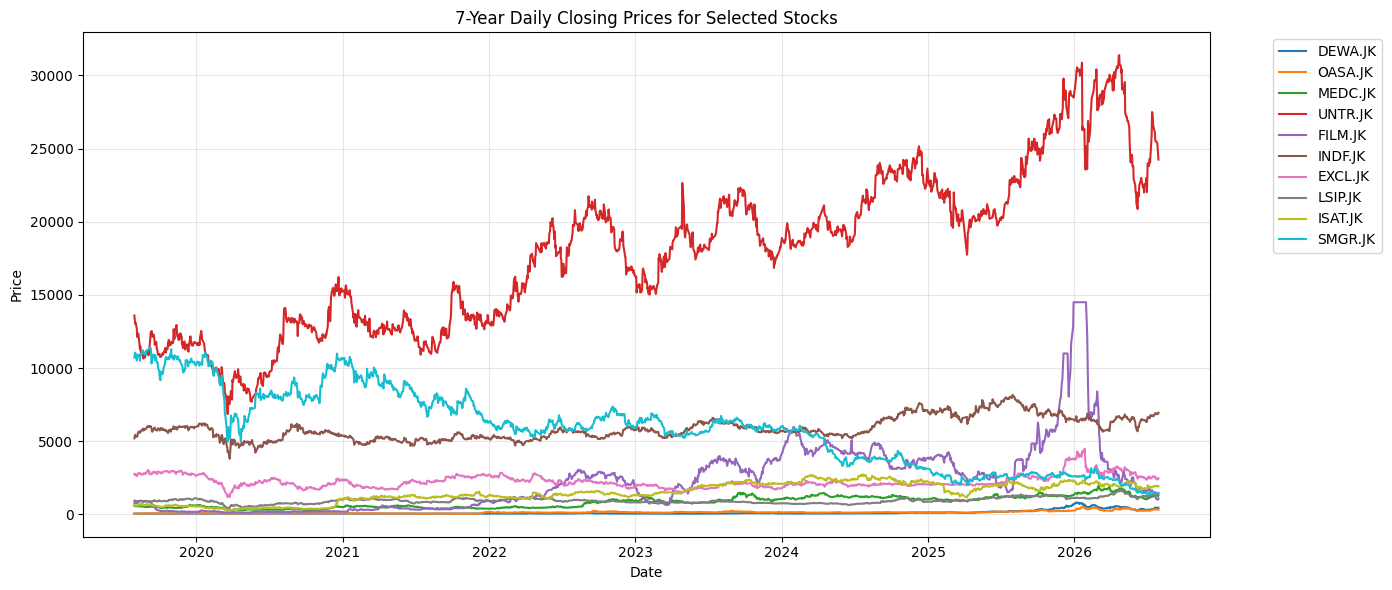

In [20]:
plt.figure(figsize=(14, 6))
for ticker in tickers:
    plt.plot(data.index, data[ticker], label=ticker)
plt.title('7-Year Daily Closing Prices for Selected Stocks')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3. Construct Equally Weighted Portfolio

In [12]:
returns = data.pct_change().dropna()
mean_daily_returns = returns.mean()
cov_matrix = returns.cov()

weights = np.full(10, 0.10) # 10% each
expected_annual_return = np.sum(mean_daily_returns * weights) * 252
portfolio_variance = np.dot(weights.T, np.dot(cov_matrix * 252, weights))
portfolio_risk = np.sqrt(portfolio_variance)

print(f"Expected Annual Return: {expected_annual_return:.4f} ({expected_annual_return*100:.2f}%)")
print(f"Annualized Risk (Volatility): {portfolio_risk:.4f} ({portfolio_risk*100:.2f}%)")

Expected Annual Return: 0.2309 (23.09%)
Annualized Risk (Volatility): 0.2561 (25.61%)


### 4. Apply a metaheuristic optimization method to minimize portfolio risk

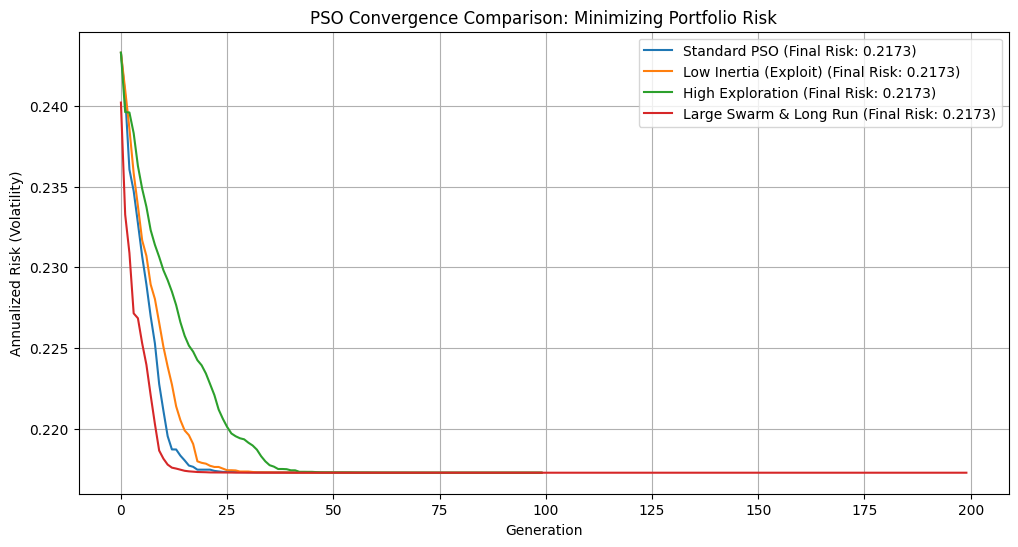

--- Best PSO Result ---
Optimal Risk: 0.2173 (21.73%)
Expected Annual Return: 0.1543 (15.43%)
Optimal Weights:
  DEWA.JK: 7.94%
  OASA.JK: 6.99%
  MEDC.JK: 2.53%
  UNTR.JK: 44.33%
  FILM.JK: 4.79%
  INDF.JK: 7.21%
  EXCL.JK: 4.21%
  LSIP.JK: 3.12%
  ISAT.JK: 5.93%
  SMGR.JK: 12.96%


In [13]:
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.soo.nonconvex.pso import PSO # we will use PSO
from pymoo.optimize import minimize
import matplotlib.pyplot as plt
import numpy as np

# 4. Single-Objective Optimization (Minimize Risk)
class PortfolioRiskProblem(ElementwiseProblem):
    def __init__(self, cov_matrix):
        super().__init__(n_var=10,
                         n_obj=1,
                         n_ieq_constr=0,
                         xl=np.zeros(10),
                         xu=np.ones(10))
        self.cov_matrix = cov_matrix

    def _evaluate(self, x, out, *args, **kwargs):
        # normalize weights so they sum to 1
        w = x / np.sum(x)
        # calculate annualized risk (volatility)
        risk = np.sqrt(np.dot(w.T, np.dot(self.cov_matrix * 252, w)))
        out["F"] = risk

problem_risk = PortfolioRiskProblem(cov_matrix)

# parameter experiment settings for PSO
experiment_settings = [
    {
        "name": "Standard PSO",
        "pop_size": 50,
        "n_gen": 100,
        "w": 0.9,
        "c1": 2.0,
        "c2": 2.0,
        "seed": 10
    },
    {
        "name": "Low Inertia (Exploit)",
        "pop_size": 50,
        "n_gen": 100,
        "w": 0.4,
        "c1": 2.0,
        "c2": 2.0,
        "seed": 10
    },
    {
        "name": "High Exploration",
        "pop_size": 50,
        "n_gen": 100,
        "w": 0.9,
        "c1": 1.0,
        "c2": 1.0,
        "seed": 10
    },
    {
        "name": "Large Swarm & Long Run",
        "pop_size": 100,
        "n_gen": 200,
        "w": 0.9,
        "c1": 2.0,
        "c2": 2.0,
        "seed": 10
    }
]

plt.figure(figsize=(12, 6))

min_risk_risk = float('inf')
min_risk_weights = None
min_risk_return = 0

# experiment loop
for setting in experiment_settings:
    algorithm_pso = PSO(pop_size=setting["pop_size"], 
                        w=setting["w"], 
                        c1=setting["c1"], 
                        c2=setting["c2"])
    
    res = minimize(problem_risk,
                   algorithm_pso,
                   ('n_gen', setting["n_gen"]),
                   seed=setting["seed"],
                   save_history=True,
                   verbose=False)
    
    # convergence history
    history = [algo.opt.get("F")[0][0] for algo in res.history]
    
    # convergence line for this setting
    plt.plot(history, label=f"{setting['name']} (Final Risk: {history[-1]:.4f})")
    
    # track the absolute best configuration found across all runs
    if history[-1] <  min_risk_risk:
        min_risk_risk = history[-1]
        min_risk_weights = res.X / np.sum(res.X)
        min_risk_return = np.sum(mean_daily_returns *  min_risk_weights) * 252

# convergence plot
plt.title('PSO Convergence Comparison: Minimizing Portfolio Risk')
plt.xlabel('Generation')
plt.ylabel('Annualized Risk (Volatility)')
plt.legend()
plt.grid()
plt.show()

# other variables
opt_risk = min_risk_risk
opt_return = min_risk_return

print(f"--- Best PSO Result ---")
print(f"Optimal Risk: {opt_risk:.4f} ({opt_risk*100:.2f}%)")
print(f"Expected Annual Return: {opt_return:.4f} ({opt_return*100:.2f}%)")
print("Optimal Weights:")
for ticker, weight in zip(tickers, min_risk_weights):
    if weight > 0.001:
        print(f"  {ticker}: {weight*100:.2f}%")

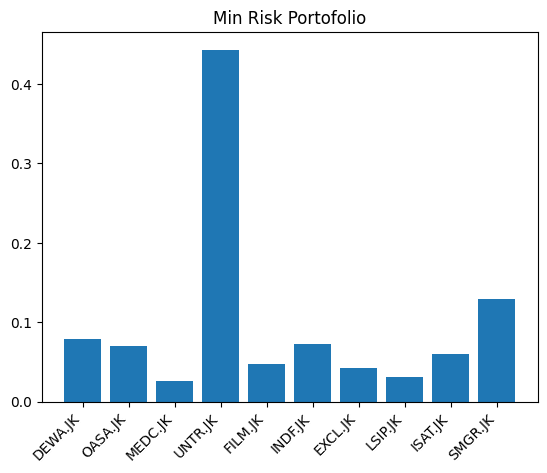

In [14]:
plt.bar(tickers, min_risk_weights)
plt.xticks(rotation=45, ha='right')
plt.title("Min Risk Portofolio")
plt.show()

### 5. Multi-Objective Optimization (Minimize Risk, Maximize Return)

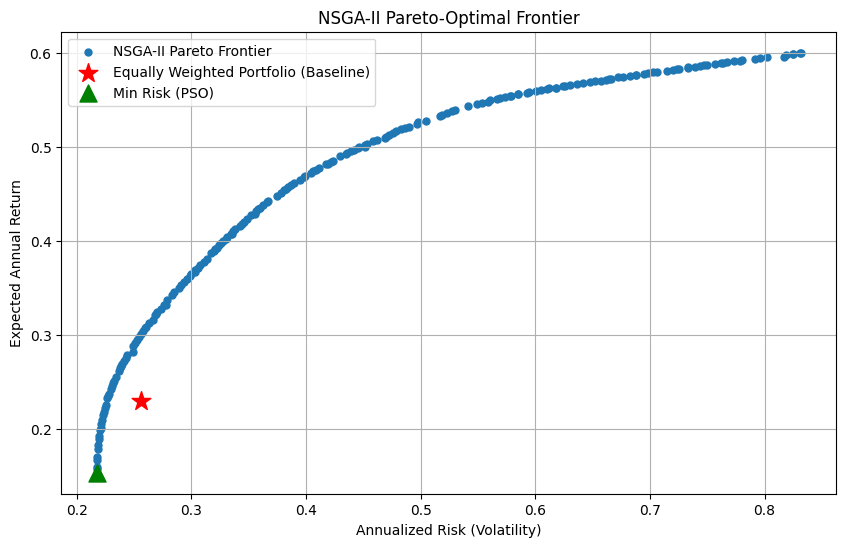

In [ ]:
from pymoo.algorithms.moo.nsga2 import NSGA2
 
 # Define a custom Multi Objective Problem
class PortfolioProblem(ElementwiseProblem):
    def __init__(self, mean_returns, cov_matrix):
        super().__init__(n_var=10,
                         n_obj=2,
                         n_ieq_constr=0,
                         xl=np.zeros(10),
                         xu=np.ones(10))
        self.mean_returns = mean_returns
        self.cov_matrix = cov_matrix

    def _evaluate(self, x, out, *args, **kwargs):
        # normalize weights so they sum to 1
        w = x / np.sum(x)
        
        # calculate annualized return and risk
        ret = np.sum(self.mean_returns * w) * 252
        risk = np.sqrt(np.dot(w.T, np.dot(self.cov_matrix * 252, w)))
        
        out["F"] = [risk, -ret]

# Create the custom problem and define the NSGA-II algorithm
problem_moo = PortfolioProblem(mean_daily_returns, cov_matrix)
algorithm_nsga2 = NSGA2(pop_size=200)

# Run the optimization process
res_moo = minimize(
    problem_moo, 
    algorithm_nsga2, 
    ('n_gen', 200), 
    seed=42, 
    verbose=False)

# Extract the decision variables and objective function values'
pareto_risk = res_moo.F[:, 0] # objective 0 is risk
pareto_return = -res_moo.F[:, 1] # objective 1 is negative return, flip sign

# Visualize the Pareto front approximation in the objective space
plt.figure(figsize=(10, 6))
plt.scatter(pareto_risk, pareto_return, s=25, label='NSGA-II Pareto Frontier') # pareto front

plt.scatter([portfolio_risk], [expected_annual_return], # equally weighted portfolio from number 3
            color='red', marker='*', s=200, zorder=5, 
            label='Equally Weighted Portfolio (Baseline)')

plt.scatter([opt_risk], [opt_return], # minimum risk portfolio from number 4
            color='green', marker='^', s=150, zorder=5, 
            label='Min Risk (PSO)')

plt.title('NSGA-II Pareto-Optimal Frontier')
plt.xlabel('Annualized Risk (Volatility)')
plt.ylabel('Expected Annual Return')
plt.legend()
plt.grid()
plt.show()

### 6: NSGA-II with Minimum-Buy Threshold Constraint (10%) 

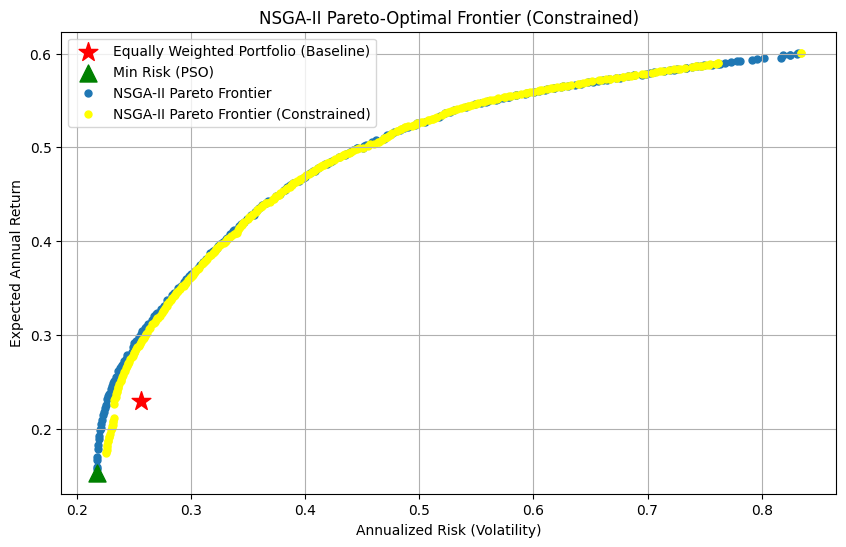

In [ ]:
from asyncio import coroutines
from pymoo.algorithms.moo.nsga2 import NSGA2
 
 # Define a custom Multi Objective Problem (constrained)
class ConstrainedPortfolioProblem6(ElementwiseProblem):
    def __init__(self, mean_returns, cov_matrix):
        super().__init__(n_var=10,
                         n_obj=2,
                         n_ieq_constr=10,
                         xl=np.zeros(10),
                         xu=np.ones(10))
        self.mean_returns = mean_returns
        self.cov_matrix = cov_matrix

    def _normalize_weights(self, x):
        # zeroes small values
        w = np.where(x < 0.05, 0, x)
        if np.sum(w) == 0:
            w = np.ones_like(x)

        # normalize
        return w / np.sum(w)

    def _evaluate(self, x, out, *args, **kwargs):
        w = self._normalize_weights(x)

        # calculate annualized return and risk
        ret = np.sum(self.mean_returns * w) * 252
        risk = np.sqrt(np.dot(w.T, np.dot(self.cov_matrix * 252, w)))

        # constraint: if selected, weight must be at least 10%
        g = np.where(w > 0.0, 0.10 - w, 0.0)

        out["F"] = [risk, -ret]
        out["G"] = g

# Create the custom problem and define the NSGA-II algorithm
problem_constrained = ConstrainedPortfolioProblem6(mean_daily_returns, cov_matrix)
algorithm_nsga2 = NSGA2(pop_size=300)

# Run the optimization process
res_constrained = minimize(
    problem_constrained, 
    algorithm_nsga2, 
    ('n_gen', 300), 
    seed=42, 
    verbose=False)

# Extract the decision variables and objective function values'
pareto_risk_constrained = res_constrained.F[:, 0] # objective 0 is risk
pareto_return_constrained = -res_constrained.F[:, 1] # objective 1 is negative return, flip sign

# Visualize the Pareto front approximation in the objective space
plt.figure(figsize=(10, 6))

plt.scatter([portfolio_risk], [expected_annual_return], # equally weighted portfolio from number 3
            color='red', marker='*', s=200, zorder=5, 
            label='Equally Weighted Portfolio (Baseline)')

plt.scatter([opt_risk], [opt_return], # minimum risk portfolio from number 4
            color='green', marker='^', s=150, zorder=5, 
            label='Min Risk (PSO)')

plt.scatter(pareto_risk, 
            pareto_return, 
            s=25, label='NSGA-II Pareto Frontier') # unconstrained pareto front from number 5

plt.scatter(pareto_risk_constrained, 
            pareto_return_constrained, 
            s=25, label='NSGA-II Pareto Frontier (Constrained)', color='yellow') # pareto front

plt.title('NSGA-II Pareto-Optimal Frontier (Constrained)')
plt.xlabel('Annualized Risk (Volatility)')
plt.ylabel('Expected Annual Return')
plt.legend()
plt.grid()
plt.show()

In [ ]:
for i in range(len(res_constrained.X)):
    w = problem_constrained._normalize_weights(res_constrained.X[i])
    if np.sum(w > 0) > 6:
        print(f"Solution {i+1}")
        print("Raw X      :", np.round(res_constrained.X[i], 3))
        print("Normalized :", np.round(w, 3))
        print("Selected   :", np.sum(w > 1e-6))
        print("Risk        :", res_constrained.F[i,0])
        print("Return      :", -res_constrained.F[i,1])
        print()

Solution 11
Raw X      : [0.767 0.023 0.409 0.599 0.675 0.502 0.008 0.521 0.048 0.395]
Normalized : [0.198 0.    0.106 0.155 0.175 0.13  0.    0.135 0.    0.102]
Selected   : 7
Risk        : 0.2726981188382687
Return      : 0.3204063964261819

Solution 19
Raw X      : [0.695 0.018 0.347 0.719 0.576 0.04  0.365 0.372 0.005 0.379]
Normalized : [0.201 0.    0.1   0.208 0.167 0.    0.106 0.108 0.    0.11 ]
Selected   : 7
Risk        : 0.26613022018209914
Return      : 0.3114034296881785

Solution 23
Raw X      : [0.696 0.    0.346 0.66  0.539 0.375 0.035 0.403 0.    0.408]
Normalized : [0.203 0.    0.101 0.193 0.157 0.109 0.    0.118 0.    0.119]
Selected   : 7
Risk        : 0.2639853266548778
Return      : 0.30768803058057687

Solution 26
Raw X      : [0.502 0.003 0.01  1.    0.391 0.368 0.348 0.349 0.005 0.452]
Normalized : [0.147 0.    0.    0.293 0.115 0.108 0.102 0.102 0.    0.133]
Selected   : 7
Risk        : 0.23937083325337172
Return      : 0.2554763199914555

Solution 32
Raw X    

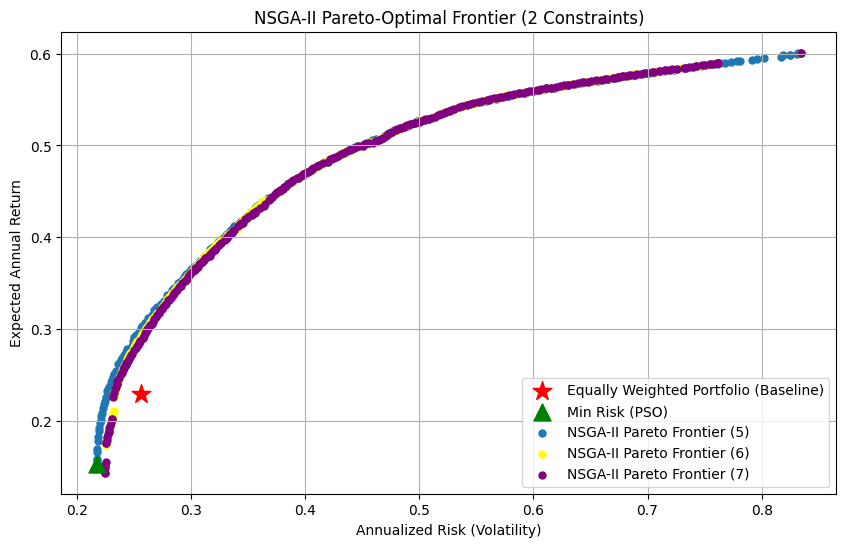

In [ ]:
from asyncio import coroutines
from pymoo.algorithms.moo.nsga2 import NSGA2
 
 # Define a custom Multi Objective Problem (constrained)
class ConstrainedPortfolioProblem7(ElementwiseProblem):
    def __init__(self, mean_returns, cov_matrix):
        super().__init__(n_var=10,
                         n_obj=2,
                         n_ieq_constr=10+1,
                         xl=np.zeros(10),
                         xu=np.ones(10))
        self.mean_returns = mean_returns
        self.cov_matrix = cov_matrix

    def _normalize_weights(self, x):
        # zeroes small values
        w = np.where(x < 0.05, 0, x)
        if np.sum(w) == 0:
            w = np.ones_like(x)

        # normalize
        return w / np.sum(w)

    def _evaluate(self, x, out, *args, **kwargs):
        w = self._normalize_weights(x)

        # calculate annualized return and risk
        ret = np.sum(self.mean_returns * w) * 252
        risk = np.sqrt(np.dot(w.T, np.dot(self.cov_matrix * 252, w)))

        # constraint 1: if selected, weight must be at least 10%
        g1 = np.where(w > 1e-6, 0.10 - w, 0.0)

        # constraint 2: at most 6 stocks
        num_selected = np.sum(w > 1e-6)
        g2 = np.array([num_selected - 6.0])

        g = np.concatenate((g1, g2))

        out["F"] = [risk, -ret]
        out["G"] = g

# Create the custom problem and define the NSGA-II algorithm
problem_7 = ConstrainedPortfolioProblem7(mean_daily_returns, cov_matrix)
algorithm_nsga2 = NSGA2(pop_size=300)

# Run the optimization process
res_7 = minimize(
    problem_7, 
    algorithm_nsga2, 
    ('n_gen', 300), 
    seed=42, 
    verbose=False)

# Extract the decision variables and objective function values'
pareto_risk_7 = res_7.F[:, 0] # objective 0 is risk
pareto_return_7 = -res_7.F[:, 1] # objective 1 is negative return, flip sign

# Visualize the Pareto front approximation in the objective space
plt.figure(figsize=(10, 6))

plt.scatter([portfolio_risk], [expected_annual_return], # equally weighted portfolio from number 3
            color='red', marker='*', s=200, zorder=5, 
            label='Equally Weighted Portfolio (Baseline)')

plt.scatter([opt_risk], [opt_return], # minimum risk portfolio from number 4
            color='green', marker='^', s=150, zorder=5, 
            label='Min Risk (PSO)')

plt.scatter(pareto_risk, 
            pareto_return, 
            s=25, label='NSGA-II Pareto Frontier (5)') # unconstrained pareto front from number 5

plt.scatter(pareto_risk_constrained, 
            pareto_return_constrained, 
            s=25, label='NSGA-II Pareto Frontier (6)', color='yellow') # pareto front number 6

plt.scatter(pareto_risk_7, 
            pareto_return_7, 
            s=25, label='NSGA-II Pareto Frontier (7)', color='purple') # pareto front

plt.title('NSGA-II Pareto-Optimal Frontier (2 Constraints)')
plt.xlabel('Annualized Risk (Volatility)')
plt.ylabel('Expected Annual Return')
plt.legend()
plt.grid()
plt.show()

In [ ]:
for i in range(min(5, len(res_7.X))):
    w = problem_7._normalize_weights(res_7.X[i])

    print(f"Solution {i+1}")
    print("Raw X      :", np.round(res_7.X[i], 3))
    print("Normalized :", np.round(w, 3))
    print("Selected   :", np.sum(w > 1e-6))
    print("Risk        :", res_7.F[i,0])
    print("Return      :", -res_7.F[i,1])
    print()

Solution 1
Raw X      : [0.001 0.026 0.013 0.019 0.011 0.015 0.024 0.719 0.02  0.001]
Normalized : [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
Selected   : 1
Risk        : 0.8344720464831015
Return      : 0.6009097111186421

Solution 2
Raw X      : [0.001 0.004 0.013 0.019 0.041 0.015 0.024 0.719 0.026 0.019]
Normalized : [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
Selected   : 1
Risk        : 0.8344720464831015
Return      : 0.6009097111186421

Solution 3
Raw X      : [0.205 0.243 0.01  0.997 0.003 0.225 0.008 0.045 0.018 0.371]
Normalized : [0.1   0.119 0.    0.489 0.    0.11  0.    0.    0.    0.182]
Selected   : 5
Risk        : 0.22437310941802327
Return      : 0.14377810404682

Solution 4
Raw X      : [0.205 0.243 0.01  0.997 0.003 0.225 0.005 0.045 0.018 0.371]
Normalized : [0.1   0.119 0.    0.489 0.    0.11  0.    0.    0.    0.182]
Selected   : 5
Risk        : 0.22437310941802327
Return      : 0.14377810404682

Solution 5
Raw X      : [0.059 0.001 0.038 0.005 0.023 0.03  0.041 0.534 0.049 0.003]
Norm